# UrbanCart Big Data Analytics  
## Complete Project — Phase 1 to Phase 4

This notebook implements the required SQL extraction, pandas data cleaning and integration, NumPy numerical analysis, and business insight visualizations using the supplied UrbanCart data.

### Included phases

1. **Phase 1 — SQL Data Extraction**
2. **Phase 2 — Data Cleaning & Integration with Pandas**
3. **Phase 3 — Numerical Analysis with NumPy**
4. **Phase 4 — Business Insights & Visualization**

In [ ]:
from pathlib import Path
import sqlite3
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Locate project folder in Colab or local execution.
candidate_roots = [
    Path.cwd(),
    Path("/content/UrbanCart_Phase1_to_Phase4"),
    Path("/content"),
]

PROJECT_DIR = None
for candidate in candidate_roots:
    if (candidate / "data" / "raw" / "ecommerce.db").exists():
        PROJECT_DIR = candidate
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not locate data/raw/ecommerce.db. "
        "Open the notebook from the project folder or upload the full ZIP."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "model_results"

for folder in [PROCESSED_DIR, CHART_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DB_PATH = RAW_DIR / "ecommerce.db"
LEGACY_PATH = RAW_DIR / "legacy_customers_export.xlsx"
CATALOG_PATH = RAW_DIR / "product_catalog_2024.xlsx"

print("Project directory:", PROJECT_DIR)
print("All required source files found:", all(p.exists() for p in [DB_PATH, LEGACY_PATH, CATALOG_PATH]))

Project directory: /mnt/data/UrbanCart_Phase1_to_Phase4
All required source files found: True


# Phase 1 — SQL Data Extraction

The ten SQL queries are stored in `queries.sql`. They use correct discount logic:

\[
\text{Net Revenue} = \text{Quantity} \times \text{Unit Price} \times (1-\text{Discount})
\]

Negative quantities are retained as returns.

In [ ]:
conn = sqlite3.connect(DB_PATH)

# Load operational tables.
customers_raw = pd.read_sql_query("SELECT * FROM customers", conn)
products_raw = pd.read_sql_query("SELECT * FROM products", conn)
orders_raw = pd.read_sql_query("SELECT * FROM orders", conn)
order_items_raw = pd.read_sql_query("SELECT * FROM order_items", conn)
reviews_raw = pd.read_sql_query("SELECT * FROM reviews", conn)
web_sessions_raw = pd.read_sql_query("SELECT * FROM web_sessions", conn)

table_inventory = pd.DataFrame({
    "table": ["customers", "products", "orders", "order_items", "reviews", "web_sessions"],
    "rows": [
        len(customers_raw), len(products_raw), len(orders_raw),
        len(order_items_raw), len(reviews_raw), len(web_sessions_raw)
    ],
    "columns": [
        customers_raw.shape[1], products_raw.shape[1], orders_raw.shape[1],
        order_items_raw.shape[1], reviews_raw.shape[1], web_sessions_raw.shape[1]
    ]
})
table_inventory

,table,rows,columns
0,customers,2500,8
1,products,300,6
2,orders,9000,5
3,order_items,20362,6
4,reviews,4000,6
5,web_sessions,12000,6


In [ ]:
# Query 1 — Revenue, completed orders, and average order value by category.
query1 = '''
SELECT
    p.category,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(
        SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0)))
        / NULLIF(COUNT(DISTINCT o.order_id), 0), 2
    ) AS average_order_value
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN orders o ON oi.order_id = o.order_id
WHERE LOWER(o.status) = 'completed'
GROUP BY p.category
ORDER BY total_revenue DESC;
'''
query1_result = pd.read_sql_query(query1, conn)
query1_result

,category,total_revenue,total_orders,average_order_value
0,Books & Media,2288541.26,1649,1387.84
1,Beauty & Health,1781007.78,1637,1087.97
2,Apparel,967057.00,1629,593.65
3,Sports & Outdoors,916247.78,1579,580.27
4,Electronics,900204.48,1615,557.40
5,Home & Kitchen,781563.91,1660,470.82


In [ ]:
# Query 2 — Top 20 customers by lifetime spending.
query2 = '''
SELECT
    c.customer_id, c.name, c.city, c.signup_date,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))), 2) AS lifetime_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE LOWER(o.status) = 'completed'
GROUP BY c.customer_id, c.name, c.city, c.signup_date
ORDER BY lifetime_spending DESC
LIMIT 20;
'''
query2_result = pd.read_sql_query(query2, conn)
query2_result.head(10)

,customer_id,name,city,signup_date,total_orders,lifetime_spending
0,611,Tara Holmes,Sydney,2021-10-15,3,145169.05
1,689,Misty Mcguire,Toronto,2020-08-25,2,107213.91
2,1259,Matthew Perez,Los Angeles,2023-02-25,2,94519.39
3,1217,Virginia Hernandez,Paris,2022-07-07,4,77530.81
4,528,Brent Hopkins,Vancouver,2023-10-12,6,72405.36
5,2445,Virginia Rose,Bangkok,2023-11-26,3,72021.09
6,1993,Chelsea Austin,Sydney,2020-04-27,1,70254.39
7,1347,Evan Davies,Paris,2020-05-28,2,70236.44
8,1533,Lauren Anthony,Vancouver,2023-10-03,5,59602.71
9,1180,Tammy Booth,Mumbai,2022-03-30,5,42127.63


In [ ]:
# Query 3 — Month-over-month revenue for the most recent 24 months.
query3 = '''
WITH monthly_revenue AS (
    SELECT
        STRFTIME('%Y-%m', o.order_date) AS revenue_month,
        SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))) AS revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE LOWER(o.status) = 'completed'
    GROUP BY STRFTIME('%Y-%m', o.order_date)
),
recent_24 AS (
    SELECT revenue_month, revenue
    FROM monthly_revenue
    ORDER BY revenue_month DESC
    LIMIT 24
),
comparison AS (
    SELECT
        revenue_month,
        revenue,
        LAG(revenue) OVER (ORDER BY revenue_month) AS previous_month_revenue
    FROM recent_24
)
SELECT
    revenue_month,
    ROUND(revenue, 2) AS revenue,
    ROUND(previous_month_revenue, 2) AS previous_month_revenue,
    ROUND(revenue - previous_month_revenue, 2) AS revenue_change,
    ROUND(
        100.0 * (revenue - previous_month_revenue)
        / NULLIF(previous_month_revenue, 0), 2
    ) AS percentage_change
FROM comparison
ORDER BY revenue_month;
'''
query3_result = pd.read_sql_query(query3, conn)
query3_result.tail()

,revenue_month,revenue,previous_month_revenue,revenue_change,percentage_change
19,2024-08,454886.62,236592.06,218294.56,92.27
20,2024-09,266306.70,454886.62,-188579.92,-41.46
21,2024-10,264457.67,266306.70,-1849.03,-0.69
22,2024-11,355747.37,264457.67,91289.70,34.52
23,2024-12,282790.87,355747.37,-72956.50,-20.51


In [ ]:
# Query 4 — Return rates by category using negative quantities.
query4 = '''
WITH category_returns AS (
    SELECT
        p.category,
        COUNT(*) AS item_rows,
        SUM(CASE WHEN oi.quantity < 0 THEN 1 ELSE 0 END) AS return_rows,
        SUM(ABS(oi.quantity)) AS total_units,
        SUM(CASE WHEN oi.quantity < 0 THEN ABS(oi.quantity) ELSE 0 END) AS returned_units
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.category
)
SELECT
    category,
    item_rows,
    return_rows,
    returned_units,
    total_units,
    ROUND(100.0 * return_rows / NULLIF(item_rows, 0), 2) AS return_row_rate_percent,
    ROUND(100.0 * returned_units / NULLIF(total_units, 0), 2) AS return_unit_rate_percent
FROM category_returns
ORDER BY return_unit_rate_percent DESC;
'''
query4_result = pd.read_sql_query(query4, conn)
query4_result

,category,item_rows,return_rows,returned_units,total_units,return_row_rate_percent,return_unit_rate_percent
0,Beauty & Health,3354,106,106,4328,3.16,2.45
1,Electronics,3401,106,106,4425,3.12,2.40
2,Apparel,3372,102,102,4355,3.02,2.34
3,Books & Media,3455,93,93,4461,2.69,2.08
4,Home & Kitchen,3468,91,91,4439,2.62,2.05
5,Sports & Outdoors,3312,85,85,4252,2.57,2.00


In [ ]:
# Query 5 — Customers active in each of the latest three calendar quarters.
query5 = '''
WITH latest AS (
    SELECT MAX(DATE(order_date)) AS max_date FROM orders
),
latest_quarter AS (
    SELECT DATE(
        STRFTIME('%Y', max_date) || '-' ||
        PRINTF('%02d', ((CAST(STRFTIME('%m', max_date) AS INTEGER)-1)/3)*3+1) ||
        '-01'
    ) AS quarter_start
    FROM latest
),
required_quarters AS (
    SELECT quarter_start FROM latest_quarter
    UNION ALL SELECT DATE(quarter_start, '-3 months') FROM latest_quarter
    UNION ALL SELECT DATE(quarter_start, '-6 months') FROM latest_quarter
),
customer_quarters AS (
    SELECT DISTINCT
        customer_id,
        DATE(
            STRFTIME('%Y', order_date) || '-' ||
            PRINTF('%02d', ((CAST(STRFTIME('%m', order_date) AS INTEGER)-1)/3)*3+1) ||
            '-01'
        ) AS quarter_start
    FROM orders
    WHERE LOWER(status) = 'completed'
)
SELECT
    c.customer_id, c.name, c.city, c.signup_date,
    COUNT(DISTINCT cq.quarter_start) AS active_required_quarters
FROM customers c
JOIN customer_quarters cq ON c.customer_id = cq.customer_id
JOIN required_quarters rq ON cq.quarter_start = rq.quarter_start
GROUP BY c.customer_id, c.name, c.city, c.signup_date
HAVING COUNT(DISTINCT cq.quarter_start) = 3
ORDER BY c.name;
'''
query5_result = pd.read_sql_query(query5, conn)
print("Customers active in all latest three quarters:", len(query5_result))
query5_result.head()

Customers active in all latest three quarters: 43


,customer_id,name,city,signup_date,active_required_quarters
0,73,Alicia Gilmore,Los Angeles,2023-01-14,3
1,2497,Anthony Velasquez,Paris,2023-09-28,3
2,2189,Bradley Brady,Toronto,2024-04-01,3
3,1036,Brenda Gray,New York,2024-06-04,3
4,528,Brent Hopkins,Vancouver,2023-10-12,3


In [ ]:
# Query 6 — Top-rated products with at least 15 valid reviews.
query6 = '''
SELECT
    p.product_id, p.name, p.category,
    COUNT(r.review_id) AS total_reviews,
    ROUND(AVG(r.rating), 2) AS average_rating
FROM products p
JOIN reviews r ON p.product_id = r.product_id
WHERE r.rating BETWEEN 1 AND 5
GROUP BY p.product_id, p.name, p.category
HAVING COUNT(r.review_id) >= 15
ORDER BY average_rating DESC, total_reviews DESC, p.name
LIMIT 10;
'''
query6_result = pd.read_sql_query(query6, conn)
query6_result

,product_id,name,category,total_reviews,average_rating
0,200,White Fitnes,Sports & Outdoors,15,4.60
1,19,Improve Smartphone,Electronics,15,4.53
2,283,Strategy Children,Books & Media,15,4.53
3,191,Yeah Camping,Sports & Outdoors,15,4.53
4,21,Right Camera,Electronics,16,4.50
5,182,Answer Fitnes,Sports & Outdoors,15,4.40
6,66,Wide Cookware,Home & Kitchen,15,4.40
7,122,Attorney Men,Apparel,17,4.35
8,208,Series Skincare,Beauty & Health,18,4.33
9,154,Attack Cycling,Sports & Outdoors,16,4.31


In [ ]:
# Query 7 — Session behavior by device for customers who completed a purchase.
query7 = '''
SELECT
    ws.device,
    COUNT(*) AS total_sessions,
    COUNT(DISTINCT ws.customer_id) AS purchasing_customers,
    ROUND(AVG(ws.duration_minutes), 2) AS average_duration_minutes,
    ROUND(AVG(ws.pages_viewed), 2) AS average_pages_viewed
FROM web_sessions ws
WHERE EXISTS (
    SELECT 1
    FROM orders o
    WHERE o.customer_id = ws.customer_id
      AND LOWER(o.status) = 'completed'
)
GROUP BY ws.device
ORDER BY average_duration_minutes DESC;
'''
query7_result = pd.read_sql_query(query7, conn)
query7_result

,device,total_sessions,purchasing_customers,average_duration_minutes,average_pages_viewed
0,desktop,3494,1776,6.25,4.68
1,mobile,3458,1719,6.20,4.65
2,tablet,3569,1761,6.09,4.74


In [ ]:
# Query 8 — Rank products by net revenue inside each category.
query8 = '''
WITH product_revenue AS (
    SELECT
        p.category, p.product_id, p.name,
        SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))) AS net_revenue
    FROM products p
    JOIN order_items oi ON p.product_id = oi.product_id
    JOIN orders o ON oi.order_id = o.order_id
    WHERE LOWER(o.status) = 'completed'
    GROUP BY p.category, p.product_id, p.name
)
SELECT
    category, product_id, name,
    ROUND(net_revenue, 2) AS net_revenue,
    DENSE_RANK() OVER (
        PARTITION BY category ORDER BY net_revenue DESC
    ) AS revenue_rank
FROM product_revenue
ORDER BY category, revenue_rank, name;
'''
query8_result = pd.read_sql_query(query8, conn)
query8_result.head(15)

,category,product_id,name,net_revenue,revenue_rank
0,Apparel,139,About Men,46240.50,1
1,Apparel,104,Major Men,45950.88,2
2,Apparel,136,Watch Footwear,45845.05,3
3,Apparel,131,Spring Kid,43443.58,4
4,Apparel,107,Appear Women,40099.07,5
5,Apparel,142,Card Footwear,39954.72,6
6,Apparel,123,Anything Footwear,39229.85,7
7,Apparel,116,Ahead Men,36435.13,8
8,Apparel,117,White Men,29974.03,9
9,Apparel,125,Increase Women,29440.15,10


In [ ]:
# Query 9 — Payment-method share within each country.
query9 = '''
WITH country_payment AS (
    SELECT
        c.country,
        o.payment_method,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    WHERE LOWER(o.status) = 'completed'
    GROUP BY c.country, o.payment_method
)
SELECT
    country, payment_method, order_count,
    ROUND(
        100.0 * order_count /
        SUM(order_count) OVER (PARTITION BY country), 2
    ) AS payment_method_share_percent
FROM country_payment
ORDER BY country, payment_method_share_percent DESC;
'''
query9_result = pd.read_sql_query(query9, conn)
query9_result.head(12)

,country,payment_method,order_count,payment_method_share_percent
0,Australia,gift_card,165,22.27
1,Australia,credit_card,162,21.86
2,Australia,debit_card,141,19.03
3,Australia,paypal,137,18.49
4,Australia,bank_transfer,136,18.35
5,Canada,credit_card,152,21.41
6,Canada,gift_card,149,20.99
7,Canada,paypal,146,20.56
8,Canada,debit_card,140,19.72
9,Canada,bank_transfer,123,17.32


In [ ]:
# Query 10 — High-value customers at risk of churn.
query10 = '''
WITH customer_activity AS (
    SELECT
        c.customer_id, c.name, c.city, c.country,
        MAX(DATE(o.order_date)) AS last_order_date,
        COUNT(DISTINCT o.order_id) AS completed_orders,
        SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))) AS lifetime_revenue
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE LOWER(o.status) = 'completed'
    GROUP BY c.customer_id, c.name, c.city, c.country
),
reference_date AS (
    SELECT MAX(DATE(order_date)) AS latest_order_date FROM orders
)
SELECT
    ca.*,
    CAST(JULIANDAY(rd.latest_order_date) - JULIANDAY(ca.last_order_date) AS INTEGER)
        AS days_since_last_order,
    CASE
        WHEN ca.lifetime_revenue >= 5000
         AND JULIANDAY(rd.latest_order_date) - JULIANDAY(ca.last_order_date) >= 90
        THEN 'High-value churn risk'
        WHEN ca.lifetime_revenue >= 5000 THEN 'High-value active'
        WHEN JULIANDAY(rd.latest_order_date) - JULIANDAY(ca.last_order_date) >= 90
        THEN 'Inactive'
        ELSE 'Active'
    END AS customer_status
FROM customer_activity ca
CROSS JOIN reference_date rd
ORDER BY
    CASE customer_status
        WHEN 'High-value churn risk' THEN 1
        WHEN 'High-value active' THEN 2
        WHEN 'Inactive' THEN 3
        ELSE 4
    END,
    lifetime_revenue DESC;
'''
query10_result = pd.read_sql_query(query10, conn)
query10_result.head(10)

,customer_id,name,city,country,last_order_date,completed_orders,lifetime_revenue,days_since_last_order,customer_status
0,689,Misty Mcguire,Toronto,Canada,2023-09-09,2,107213.9140,479,High-value churn risk
1,1259,Matthew Perez,Los Angeles,USA,2024-07-11,2,94519.3900,173,High-value churn risk
2,1217,Virginia Hernandez,Paris,France,2024-08-12,4,77530.8095,141,High-value churn risk
3,1993,Chelsea Austin,Sydney,Australia,2022-03-23,1,70254.3900,1014,High-value churn risk
4,1347,Evan Davies,Paris,France,2023-08-23,2,70236.4400,496,High-value churn risk
5,1180,Tammy Booth,Mumbai,India,2024-08-14,5,42127.6270,139,High-value churn risk
6,634,Dr. Samuel Holmes DDS,New York,USA,2024-08-26,6,41632.4925,127,High-value churn risk
7,1357,Ashley Cordova,Singapore,Singapore,2024-01-31,4,39417.3030,335,High-value churn risk
8,1999,Kayla Fisher,Chicago,USA,2024-02-11,6,38890.8540,324,High-value churn risk
9,123,Mary Grimes,Chicago,USA,2024-04-05,4,38698.7715,270,High-value churn risk


In [ ]:
# Save all SQL outputs so Phase 1 remains connected to the Python pipeline.
phase1_outputs = {
    "query01_category_revenue": query1_result,
    "query02_top_customers": query2_result,
    "query03_monthly_revenue_24m": query3_result,
    "query04_category_returns": query4_result,
    "query05_three_quarter_customers": query5_result,
    "query06_top_rated_products": query6_result,
    "query07_device_sessions": query7_result,
    "query08_product_revenue_rank": query8_result,
    "query09_country_payment_mix": query9_result,
    "query10_churn_risk": query10_result,
}

for name, frame in phase1_outputs.items():
    frame.to_csv(TABLE_DIR / f"{name}.csv", index=False)

print("Phase 1 complete: 10 SQL results exported.")

Phase 1 complete: 10 SQL results exported.


# Phase 2 — Data Cleaning & Integration with Pandas

Required tasks completed:

- Load database and external files
- Handle missing values
- Remove duplicates and near-duplicates
- Standardize dates
- Detect price outliers
- Reconcile the supplier product catalog
- Build a pivot table
- Produce a time series
- Save clean datasets and audit evidence

In [ ]:
legacy_raw = pd.read_excel(LEGACY_PATH)
catalog_raw = pd.read_excel(CATALOG_PATH)

source_inventory = []
all_sources = {
    "customers": customers_raw, "products": products_raw, "orders": orders_raw,
    "order_items": order_items_raw, "reviews": reviews_raw,
    "web_sessions": web_sessions_raw, "legacy_customers": legacy_raw,
    "supplier_catalog": catalog_raw
}
for name, frame in all_sources.items():
    source_inventory.append({
        "dataset": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "missing_cells": int(frame.isna().sum().sum()),
        "exact_duplicate_rows": int(frame.duplicated().sum())
    })
source_inventory = pd.DataFrame(source_inventory)
source_inventory.to_csv(TABLE_DIR / "phase2_initial_inventory.csv", index=False)
source_inventory

,dataset,rows,columns,missing_cells,exact_duplicate_rows
0,customers,2500,8,317,0
1,products,300,6,0,0
2,orders,9000,5,0,0
3,order_items,20362,6,0,0
4,reviews,4000,6,838,0
5,web_sessions,12000,6,0,0
6,legacy_customers,1427,5,366,0
7,supplier_catalog,267,6,0,0


In [ ]:
def normalize_column_name(value):
    value = re.sub(r"[^a-zA-Z0-9]+", "_", str(value).strip().lower())
    return re.sub(r"_+", "_", value).strip("_")

# Clean legacy customer export.
legacy = legacy_raw.copy()
legacy.columns = [normalize_column_name(c) for c in legacy.columns]
legacy = legacy.rename(columns={
    "customer_name": "name",
    "email_addr": "email",
    "signup_dt": "signup_date",
    "home_city": "city",
    "marketing_segment": "marketing_segment",
})

for col in legacy.select_dtypes(include="object").columns:
    legacy[col] = legacy[col].astype("string").str.strip()
    legacy[col] = legacy[col].replace(
        {"": pd.NA, "nan": pd.NA, "none": pd.NA, "null": pd.NA, "n/a": pd.NA}
    )

legacy["name"] = legacy["name"].str.replace(r"\s+", " ", regex=True).str.title()
legacy["email"] = legacy["email"].str.replace(r"\s+", "", regex=True).str.lower()
legacy["city"] = legacy["city"].str.replace(r"\s+", " ", regex=True).str.title()

original_legacy_rows = len(legacy)
legacy = legacy.dropna(how="all", subset=["name", "email", "signup_date", "city"])

junk_mask = (
    legacy["name"].fillna("").str.lower().str.contains(r"\b(test|dummy|sample|fake)\b", regex=True)
    | legacy["email"].fillna("").str.lower().str.contains(r"\b(test|dummy|sample|fake)\b", regex=True)
)
legacy_junk = legacy.loc[junk_mask].copy()
legacy = legacy.loc[~junk_mask].copy()

legacy["signup_date_original"] = legacy["signup_date"]
legacy["signup_date"] = pd.to_datetime(legacy["signup_date"], errors="coerce", format="mixed")

legacy["normalized_email"] = legacy["email"].fillna("").str.lower().str.replace(r"\s+", "", regex=True)
legacy["normalized_name"] = legacy["name"].fillna("").str.lower().str.replace(r"[^a-z0-9]", "", regex=True)

legacy_exact_duplicates = legacy.loc[legacy.duplicated(keep=False)].copy()
legacy = legacy.drop_duplicates().copy()

def most_complete(group):
    group = group.copy()
    completeness = group.notna().sum(axis=1)
    base = group.loc[completeness.idxmax()].copy()
    for col in group.columns:
        if pd.isna(base[col]):
            values = group[col].dropna()
            if len(values):
                base[col] = values.iloc[0]
    return base

with_email = legacy[legacy["normalized_email"].ne("")].copy()
without_email = legacy[legacy["normalized_email"].eq("")].copy()
resolved = (
    with_email.groupby("normalized_email", group_keys=False)
    .apply(most_complete)
    .reset_index(drop=True)
)
legacy_clean = pd.concat([resolved, without_email], ignore_index=True)

legacy_cleaning_summary = pd.DataFrame({
    "metric": [
        "Original rows", "Blank/junk rows removed", "Exact duplicates found",
        "Rows after near-duplicate resolution", "Unparsed signup dates",
        "Rows with missing email"
    ],
    "value": [
        original_legacy_rows,
        original_legacy_rows - len(legacy_raw.dropna(how="all")) + len(legacy_junk),
        len(legacy_exact_duplicates),
        len(legacy_clean),
        int(legacy_clean["signup_date"].isna().sum()),
        int(legacy_clean["email"].isna().sum())
    ]
})
legacy_cleaning_summary

,metric,value
0,Original rows,1427
1,Blank/junk rows removed,2
2,Exact duplicates found,0
3,Rows after near-duplicate resolution,1377
4,Unparsed signup dates,0
5,Rows with missing email,56


In [ ]:
# Missing-value policies and date standardization.
customers_clean = customers_raw.copy()
reviews_clean = reviews_raw.copy()
orders_clean = orders_raw.copy()
web_sessions_clean = web_sessions_raw.copy()

customers_clean["signup_date"] = pd.to_datetime(customers_clean["signup_date"], errors="coerce")
orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"], errors="coerce")
reviews_clean["review_date"] = pd.to_datetime(reviews_clean["review_date"], errors="coerce")
web_sessions_clean["session_date"] = pd.to_datetime(web_sessions_clean["session_date"], errors="coerce")

customers_clean["age"] = pd.to_numeric(customers_clean["age"], errors="coerce")
customers_clean["age_was_missing"] = customers_clean["age"].isna()
age_median = float(customers_clean["age"].median())
customers_clean["age"] = customers_clean["age"].fillna(age_median)

for col in ["city", "gender"]:
    customers_clean[f"{col}_was_missing"] = customers_clean[col].isna() | customers_clean[col].astype("string").str.strip().eq("")
customers_clean["city"] = customers_clean["city"].astype("string").str.strip().replace("", pd.NA).fillna("Unknown").str.title()
customers_clean["gender"] = (
    customers_clean["gender"].astype("string").str.strip().str.title()
    .replace({"Female": "F", "Male": "M", "": pd.NA})
    .fillna("Unknown")
)

reviews_clean["review_text_was_missing"] = (
    reviews_clean["review_text"].isna()
    | reviews_clean["review_text"].astype("string").str.strip().eq("")
)
reviews_clean["review_text"] = (
    reviews_clean["review_text"].astype("string").str.strip()
    .replace("", pd.NA).fillna("No written review")
)
reviews_clean["rating"] = pd.to_numeric(reviews_clean["rating"], errors="coerce")
invalid_ratings = reviews_clean.loc[~reviews_clean["rating"].between(1, 5)].copy()
reviews_clean.loc[~reviews_clean["rating"].between(1, 5), "rating"] = np.nan

missing_policy = pd.DataFrame({
    "field": ["age", "city", "gender", "review_text", "rating"],
    "policy": [
        f"Median imputation ({age_median:.1f}) with missing flag",
        "Unknown with missing flag",
        "Unknown with missing flag",
        "No written review with missing flag",
        "Outside 1–5 converted to missing and audited"
    ],
    "affected_rows": [
        int(customers_clean["age_was_missing"].sum()),
        int(customers_clean["city_was_missing"].sum()),
        int(customers_clean["gender_was_missing"].sum()),
        int(reviews_clean["review_text_was_missing"].sum()),
        len(invalid_ratings)
    ]
})
missing_policy

,field,policy,affected_rows
0,age,Median imputation (46.0) with missing flag,139
1,city,Unknown with missing flag,63
2,gender,Unknown with missing flag,115
3,review_text,No written review with missing flag,838
4,rating,Outside 1–5 converted to missing and audited,41


In [ ]:
# Product-price outliers with the IQR rule.
products_clean = products_raw.copy()
products_clean["unit_price"] = pd.to_numeric(products_clean["unit_price"], errors="coerce")
products_clean["cost"] = pd.to_numeric(products_clean["cost"], errors="coerce")

q1 = products_clean["unit_price"].quantile(0.25)
q3 = products_clean["unit_price"].quantile(0.75)
iqr = q3 - q1
lower_bound = max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

products_clean["unit_price_original"] = products_clean["unit_price"]
products_clean["unit_price_is_outlier"] = (
    (products_clean["unit_price"] < lower_bound)
    | (products_clean["unit_price"] > upper_bound)
)
price_outliers = products_clean.loc[products_clean["unit_price_is_outlier"]].copy()
products_clean["unit_price"] = products_clean["unit_price"].clip(lower_bound, upper_bound)
products_clean["cost_greater_than_price"] = products_clean["cost"] > products_clean["unit_price"]

outlier_summary = pd.DataFrame({
    "metric": ["Q1", "Q3", "IQR", "Lower bound", "Upper bound", "Outliers found"],
    "value": [q1, q3, iqr, lower_bound, upper_bound, len(price_outliers)]
})
outlier_summary

,metric,value
0,Q1,192.3325
1,Q3,579.5425
2,IQR,387.2100
3,Lower bound,0.0000
4,Upper bound,1160.3575
5,Outliers found,3.0000


In [ ]:
# Clean order items, remove business-field duplicates, and retain returns.
order_items_clean = order_items_raw.copy()
duplicate_subset = ["order_id", "product_id", "quantity", "unit_price", "discount"]
duplicate_order_items = order_items_clean.loc[
    order_items_clean.duplicated(subset=duplicate_subset, keep="first")
].copy()
order_items_clean = order_items_clean.drop_duplicates(subset=duplicate_subset, keep="first").copy()

order_items_clean["is_return"] = order_items_clean["quantity"] < 0
order_items_clean["is_sale"] = order_items_clean["quantity"] > 0
order_items_clean["discount_valid"] = order_items_clean["discount"].between(0, 1)
invalid_discounts = order_items_clean.loc[~order_items_clean["discount_valid"]].copy()
order_items_clean["discount_for_calculation"] = order_items_clean["discount"].where(
    order_items_clean["discount_valid"], 0
).fillna(0)
order_items_clean["gross_revenue"] = order_items_clean["quantity"] * order_items_clean["unit_price"]
order_items_clean["net_revenue"] = (
    order_items_clean["quantity"]
    * order_items_clean["unit_price"]
    * (1 - order_items_clean["discount_for_calculation"])
)
order_items_clean["sales_revenue"] = np.where(
    order_items_clean["quantity"] > 0, order_items_clean["net_revenue"], 0
)
order_items_clean["return_value"] = np.where(
    order_items_clean["quantity"] < 0, -order_items_clean["net_revenue"], 0
)

order_item_summary = pd.DataFrame({
    "metric": ["Raw rows", "Duplicates removed", "Clean rows", "Return rows", "Net revenue"],
    "value": [
        len(order_items_raw), len(duplicate_order_items), len(order_items_clean),
        int(order_items_clean["is_return"].sum()),
        round(order_items_clean["net_revenue"].sum(), 2)
    ]
})
order_item_summary

,metric,value
0,Raw rows,20362.00
1,Duplicates removed,186.00
2,Clean rows,20176.00
3,Return rows,577.00
4,Net revenue,12968797.33


In [ ]:
# Reconcile supplier product catalog with internal products.
catalog = catalog_raw.copy()
catalog.columns = [normalize_column_name(c) for c in catalog.columns]
catalog = catalog.rename(columns={
    "sku": "product_id",
    "item_name": "supplier_name",
    "dept": "supplier_category",
    "list_price_usd": "supplier_unit_price",
    "supplier_cost": "supplier_cost",
    "in_stock_units": "in_stock_units",
})
catalog["product_id"] = pd.to_numeric(catalog["product_id"], errors="coerce")
catalog = catalog.dropna(subset=["product_id"]).drop_duplicates(subset=["product_id"]).copy()

internal = products_clean.rename(columns={
    "name": "database_name",
    "category": "database_category",
    "subcategory": "database_subcategory",
    "unit_price": "database_unit_price",
    "cost": "database_cost",
})

product_reconciliation = internal.merge(
    catalog, on="product_id", how="outer", indicator=True
)
product_reconciliation["source_status"] = product_reconciliation["_merge"].map({
    "both": "Both sources",
    "left_only": "Database only",
    "right_only": "Supplier only",
}).astype("string")

supplier_only = product_reconciliation[
    product_reconciliation["source_status"].eq("Supplier only")
].copy()
database_only = product_reconciliation[
    product_reconciliation["source_status"].eq("Database only")
].copy()
matched = product_reconciliation[
    product_reconciliation["source_status"].eq("Both sources")
].copy()

products_reconciled = pd.DataFrame({
    "product_id": product_reconciliation["product_id"],
    "name": product_reconciliation["database_name"].combine_first(product_reconciliation["supplier_name"]),
    "category": product_reconciliation["database_category"].combine_first(product_reconciliation["supplier_category"]),
    "subcategory": product_reconciliation["database_subcategory"],
    "unit_price": product_reconciliation["database_unit_price"].combine_first(product_reconciliation["supplier_unit_price"]),
    "cost": product_reconciliation["database_cost"].combine_first(product_reconciliation["supplier_cost"]),
    "in_stock_units": product_reconciliation["in_stock_units"],
    "source_status": product_reconciliation["source_status"],
}).sort_values("product_id").reset_index(drop=True)

reconciliation_summary = pd.DataFrame({
    "metric": ["Internal products", "Supplier products", "Matched", "Supplier only", "Database only"],
    "value": [len(internal), len(catalog), len(matched), len(supplier_only), len(database_only)]
})
reconciliation_summary

,metric,value
0,Internal products,300
1,Supplier products,267
2,Matched,255
3,Supplier only,12
4,Database only,45


In [ ]:
# Integrated transaction table, pivot table, and weekly time series.
transaction_data = (
    order_items_clean
    .merge(
        orders_clean[["order_id", "customer_id", "order_date", "status", "payment_method"]],
        on="order_id", how="left"
    )
    .merge(
        products_clean[["product_id", "name", "category", "subcategory", "cost"]],
        on="product_id", how="left"
    )
)
transaction_data["status"] = transaction_data["status"].astype("string").str.lower()
completed_transactions = transaction_data[
    transaction_data["status"].eq("completed")
    & transaction_data["order_date"].notna()
].copy()
completed_transactions["order_month"] = completed_transactions["order_date"].dt.to_period("M").dt.to_timestamp()
completed_transactions["profit"] = (
    completed_transactions["net_revenue"]
    - completed_transactions["quantity"] * completed_transactions["cost"]
)

category_month_pivot = pd.pivot_table(
    completed_transactions,
    index="category",
    columns="order_month",
    values="net_revenue",
    aggfunc="sum",
    fill_value=0,
).sort_index().sort_index(axis=1)

completed_orders_indexed = (
    orders_clean[
        orders_clean["status"].astype("string").str.lower().eq("completed")
        & orders_clean["order_date"].notna()
    ]
    .sort_values("order_date")
    .set_index("order_date")
)
weekly_active = completed_orders_indexed["customer_id"].resample("W").nunique().rename("active_customers")
weekly_orders = completed_orders_indexed["order_id"].resample("W").nunique().rename("completed_orders")
weekly_revenue = (
    completed_transactions[["order_date", "net_revenue"]]
    .set_index("order_date")["net_revenue"]
    .resample("W").sum()
    .rename("net_revenue")
)
weekly_time_series = pd.concat([weekly_active, weekly_orders, weekly_revenue], axis=1).fillna(0)
weekly_time_series["revenue_per_active_customer"] = np.where(
    weekly_time_series["active_customers"] > 0,
    weekly_time_series["net_revenue"] / weekly_time_series["active_customers"],
    0
)
weekly_time_series["active_customers_4_week_ma"] = weekly_time_series["active_customers"].rolling(4, min_periods=1).mean()
weekly_time_series["revenue_4_week_ma"] = weekly_time_series["net_revenue"].rolling(4, min_periods=1).mean()

print("Pivot shape:", category_month_pivot.shape)
print("Weekly time-series rows:", len(weekly_time_series))
print("Pivot revenue validation difference:",
      round(completed_transactions["net_revenue"].sum() - category_month_pivot.to_numpy().sum(), 8))

Pivot shape: (6, 36)
Weekly time-series rows: 158
Pivot revenue validation difference: 0.0


In [ ]:
# Export clean datasets and audit evidence.
clean_exports = {
    "clean_customers.csv": customers_clean,
    "clean_products.csv": products_reconciled,
    "clean_orders.csv": orders_clean,
    "clean_order_items.csv": order_items_clean,
    "clean_reviews.csv": reviews_clean,
    "clean_web_sessions.csv": web_sessions_clean,
    "clean_legacy_customers.csv": legacy_clean,
    "category_month_revenue_pivot.csv": category_month_pivot.reset_index(),
    "weekly_customer_activity.csv": weekly_time_series.reset_index(),
}
for filename, frame in clean_exports.items():
    frame.to_csv(PROCESSED_DIR / filename, index=False)

audit_exports = {
    "phase2_legacy_cleaning_summary.csv": legacy_cleaning_summary,
    "phase2_missing_value_policy.csv": missing_policy,
    "phase2_price_outliers.csv": price_outliers,
    "phase2_duplicate_order_items.csv": duplicate_order_items,
    "phase2_product_reconciliation_summary.csv": reconciliation_summary,
    "phase2_supplier_only_products.csv": supplier_only,
    "phase2_database_only_products.csv": database_only,
}
for filename, frame in audit_exports.items():
    frame.to_csv(TABLE_DIR / filename, index=False)

print("Phase 2 complete:", len(clean_exports), "clean datasets exported.")

Phase 2 complete: 9 clean datasets exported.


# Phase 3 — Numerical Analysis with NumPy

This phase implements:

1. RFM segmentation
2. Cosine-similarity product recommendations
3. Linear regression using the Normal Equation
4. Monte Carlo simulation with at least 5,000 trials

In [ ]:
# RFM segmentation using NumPy.
reference_date = orders_clean["order_date"].max().normalize() + pd.Timedelta(days=1)

customer_transactions = completed_transactions.groupby("customer_id").agg(
    last_order_date=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("net_revenue", "sum"),
).reset_index()

customer_transactions["recency"] = (
    reference_date - customer_transactions["last_order_date"].dt.normalize()
).dt.days

rfm_values = customer_transactions[["recency", "frequency", "monetary"]].to_numpy(dtype=float)

# NumPy percentile thresholds.
r_bins = np.percentile(rfm_values[:, 0], [20, 40, 60, 80])
f_bins = np.percentile(rfm_values[:, 1], [20, 40, 60, 80])
m_bins = np.percentile(rfm_values[:, 2], [20, 40, 60, 80])

r_score = 5 - np.digitize(rfm_values[:, 0], r_bins, right=True)
f_score = 1 + np.digitize(rfm_values[:, 1], f_bins, right=True)
m_score = 1 + np.digitize(rfm_values[:, 2], m_bins, right=True)

customer_transactions["R"] = r_score
customer_transactions["F"] = f_score
customer_transactions["M"] = m_score
customer_transactions["rfm_score"] = r_score + f_score + m_score

conditions = [
    (r_score >= 4) & (f_score >= 4) & (m_score >= 4),
    (r_score >= 4) & (f_score >= 3),
    (r_score <= 2) & (f_score >= 3) & (m_score >= 3),
    (r_score <= 2) & (f_score <= 2),
]
labels = ["Champions", "Loyal", "At Risk", "Hibernating"]
customer_transactions["rfm_segment"] = np.select(conditions, labels, default="Potential")

rfm_summary = customer_transactions.groupby("rfm_segment").agg(
    customers=("customer_id", "count"),
    average_recency=("recency", "mean"),
    average_frequency=("frequency", "mean"),
    total_revenue=("monetary", "sum"),
).reset_index().sort_values("total_revenue", ascending=False)

customer_transactions.to_csv(MODEL_DIR / "rfm_customer_segments.csv", index=False)
rfm_summary.to_csv(MODEL_DIR / "rfm_segment_summary.csv", index=False)
rfm_summary

,rfm_segment,customers,average_recency,average_frequency,total_revenue
1,Champions,329,67.969605,4.015198,2.455159e+06
4,Potential,894,162.116331,2.062640,2.413433e+06
2,Hibernating,682,601.074780,1.414956,1.540737e+06
0,At Risk,169,481.426036,3.473373,9.645197e+05
3,Loyal,117,68.965812,3.282051,1.956400e+05


In [ ]:
# Cosine-similarity recommendation using NumPy only for similarity.
purchase_matrix_df = pd.pivot_table(
    completed_transactions[completed_transactions["quantity"] > 0],
    index="customer_id",
    columns="product_id",
    values="quantity",
    aggfunc="sum",
    fill_value=0,
)

X = purchase_matrix_df.to_numpy(dtype=float)
product_vectors = X.T
norms = np.linalg.norm(product_vectors, axis=1, keepdims=True)
safe_norms = np.where(norms == 0, 1, norms)
normalized_vectors = product_vectors / safe_norms
cosine_similarity = normalized_vectors @ normalized_vectors.T
np.fill_diagonal(cosine_similarity, 0)

product_ids = purchase_matrix_df.columns.to_numpy()
product_name_map = products_clean.set_index("product_id")["name"].to_dict()

recommendation_rows = []
for i, product_id in enumerate(product_ids):
    top_indices = np.argsort(cosine_similarity[i])[::-1][:5]
    for rank, j in enumerate(top_indices, start=1):
        recommendation_rows.append({
            "product_id": int(product_id),
            "product_name": product_name_map.get(product_id, "Unknown"),
            "recommended_product_id": int(product_ids[j]),
            "recommended_product_name": product_name_map.get(product_ids[j], "Unknown"),
            "similarity": float(cosine_similarity[i, j]),
            "rank": rank,
        })

product_recommendations = pd.DataFrame(recommendation_rows)
product_recommendations.to_csv(MODEL_DIR / "cosine_product_recommendations.csv", index=False)
product_recommendations.head(10)

,product_id,product_name,recommended_product_id,recommended_product_name,similarity,rank
0,1,Black Camera,184,Important Cycling,0.109859,1
1,1,Black Camera,244,Thus Supplement,0.109082,2
2,1,Black Camera,90,Group Furniture,0.108927,3
3,1,Black Camera,97,Black Appliance,0.108927,4
4,1,Black Camera,293,Almost Non-Fiction,0.107879,5
5,2,Maintain Laptop,132,Set Men,0.113081,1
6,2,Maintain Laptop,95,They Appliance,0.097743,2
7,2,Maintain Laptop,149,Move Kid,0.094013,3
8,2,Maintain Laptop,257,Minute Children,0.091505,4
9,2,Maintain Laptop,164,Great Team Sport,0.085470,5


In [ ]:
# Linear regression with the Normal Equation.
# Predict monthly revenue using time index, completed orders, active customers, and average discount.
monthly_model_data = completed_transactions.groupby("order_month").agg(
    revenue=("net_revenue", "sum"),
    completed_orders=("order_id", "nunique"),
    active_customers=("customer_id", "nunique"),
    average_discount=("discount_for_calculation", "mean"),
).reset_index().sort_values("order_month")

monthly_model_data["time_index"] = np.arange(len(monthly_model_data))
X_reg = monthly_model_data[
    ["time_index", "completed_orders", "active_customers", "average_discount"]
].to_numpy(dtype=float)
y_reg = monthly_model_data["revenue"].to_numpy(dtype=float)

# Standardize predictors with NumPy, then add intercept.
means = X_reg.mean(axis=0)
stds = X_reg.std(axis=0)
stds = np.where(stds == 0, 1, stds)
X_scaled = (X_reg - means) / stds
X_design = np.column_stack([np.ones(len(X_scaled)), X_scaled])

beta = np.linalg.pinv(X_design.T @ X_design) @ X_design.T @ y_reg
predicted = X_design @ beta
residuals = y_reg - predicted

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y_reg - y_reg.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean(residuals ** 2))
mae = np.mean(np.abs(residuals))

regression_results = monthly_model_data.copy()
regression_results["predicted_revenue"] = predicted
regression_results["residual"] = residuals

# Forecast next two months using recent means for business drivers.
future_rows = []
last_month = monthly_model_data["order_month"].max()
for step in [1, 2]:
    features = np.array([[
        monthly_model_data["time_index"].max() + step,
        monthly_model_data["completed_orders"].tail(6).mean(),
        monthly_model_data["active_customers"].tail(6).mean(),
        monthly_model_data["average_discount"].tail(6).mean(),
    ]])
    scaled = (features - means) / stds
    design = np.column_stack([np.ones(len(scaled)), scaled])
    forecast = float(design @ beta)
    future_rows.append({
        "forecast_month": last_month + pd.DateOffset(months=step),
        "forecast_revenue": forecast,
    })

forecast_results = pd.DataFrame(future_rows)
regression_metrics = pd.DataFrame({
    "metric": ["R-squared", "RMSE", "MAE"],
    "value": [r_squared, rmse, mae]
})
regression_results.to_csv(MODEL_DIR / "normal_equation_regression.csv", index=False)
forecast_results.to_csv(MODEL_DIR / "two_month_revenue_forecast.csv", index=False)
regression_metrics.to_csv(MODEL_DIR / "regression_metrics.csv", index=False)

regression_metrics

,metric,value
0,R-squared,0.679679
1,RMSE,51892.621208
2,MAE,41098.307378


In [ ]:
# Monte Carlo simulation — 10,000 trials.
rng = np.random.default_rng(42)
monthly_revenue = monthly_model_data["revenue"].to_numpy()
growth_rates = np.diff(monthly_revenue) / monthly_revenue[:-1]
growth_rates = growth_rates[np.isfinite(growth_rates)]

trials = 10_000
months_ahead = 2
simulated = np.empty((trials, months_ahead))
last_revenue = monthly_revenue[-1]

for trial in range(trials):
    current = last_revenue
    sampled_growth = rng.choice(growth_rates, size=months_ahead, replace=True)
    for month_index, growth in enumerate(sampled_growth):
        current = current * (1 + growth)
        simulated[trial, month_index] = current

simulation_summary = []
for month_index in range(months_ahead):
    values = simulated[:, month_index]
    simulation_summary.append({
        "month_ahead": month_index + 1,
        "mean_revenue": values.mean(),
        "median_revenue": np.median(values),
        "p05": np.percentile(values, 5),
        "p95": np.percentile(values, 95),
        "probability_below_current": np.mean(values < last_revenue),
    })

simulation_summary = pd.DataFrame(simulation_summary)
np.save(MODEL_DIR / "monte_carlo_trials.npy", simulated)
simulation_summary.to_csv(MODEL_DIR / "monte_carlo_summary.csv", index=False)
simulation_summary

,month_ahead,mean_revenue,median_revenue,p05,p95,probability_below_current
0,1,313324.252198,282998.667709,162331.084196,552418.533489,0.4817
1,2,351168.747045,286481.300410,125518.474029,803794.007683,0.4842


# Phase 4 — Business Insights & Visualization

The following eight business questions are answered with cleaned data, charts, and concise interpretations.

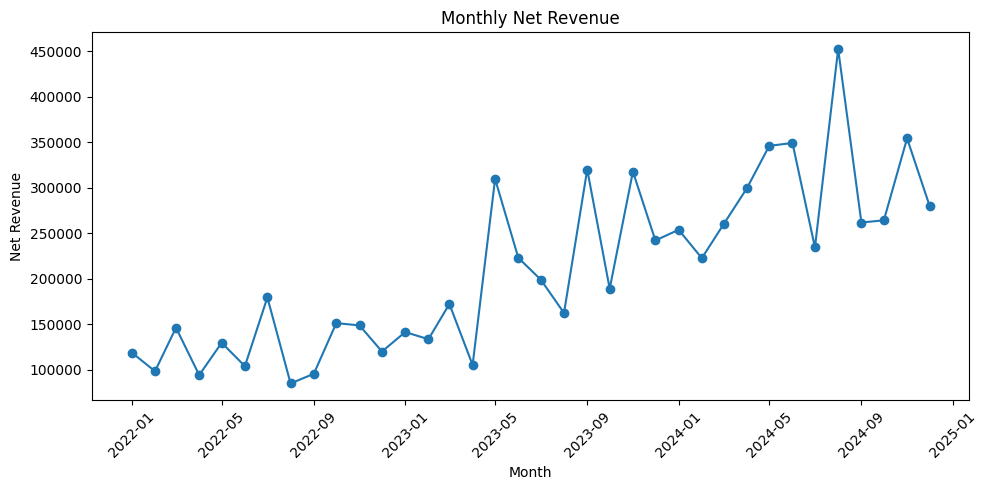

Interpretation: Revenue peaked in 2024-08 at 452,538.75. Management should compare promotions, inventory availability, and acquisition activity during peak months.


In [ ]:
# BQ1 — How is monthly net revenue changing?
monthly_revenue_insight = completed_transactions.groupby("order_month", as_index=False)["net_revenue"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue_insight["order_month"], monthly_revenue_insight["net_revenue"], marker="o")
plt.title("Monthly Net Revenue")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / "bq1_monthly_net_revenue.png", dpi=160)
plt.show()

best_month = monthly_revenue_insight.loc[monthly_revenue_insight["net_revenue"].idxmax()]
print(
    f"Interpretation: Revenue peaked in {best_month['order_month']:%Y-%m} "
    f"at {best_month['net_revenue']:,.2f}. Management should compare promotions, "
    "inventory availability, and acquisition activity during peak months."
)

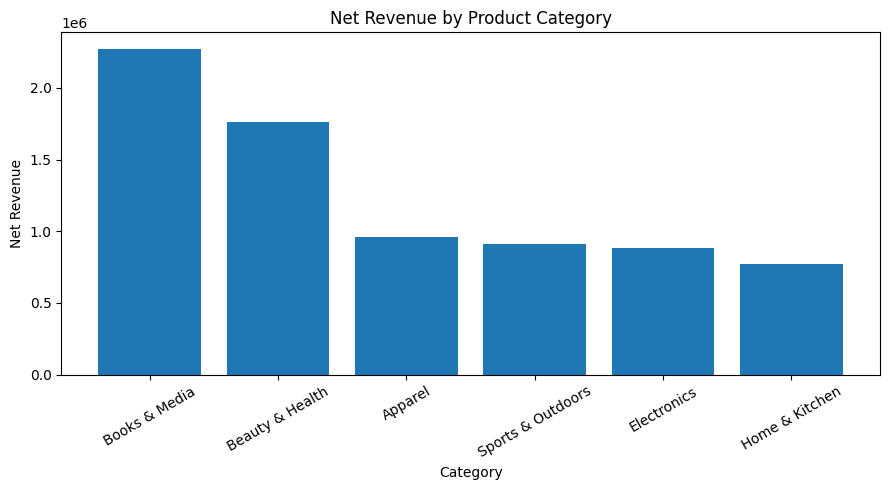

Interpretation: Books & Media leads category revenue at 2,274,551.94. Budget and inventory planning should protect availability in this category while also considering profit, not revenue alone.


In [ ]:
# BQ2 — Which categories generate the most revenue and profit?
category_performance = completed_transactions.groupby("category", as_index=False).agg(
    net_revenue=("net_revenue", "sum"),
    profit=("profit", "sum"),
).sort_values("net_revenue", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(category_performance["category"], category_performance["net_revenue"])
plt.title("Net Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(CHART_DIR / "bq2_category_revenue.png", dpi=160)
plt.show()

leader = category_performance.iloc[0]
print(
    f"Interpretation: {leader['category']} leads category revenue at "
    f"{leader['net_revenue']:,.2f}. Budget and inventory planning should protect "
    "availability in this category while also considering profit, not revenue alone."
)

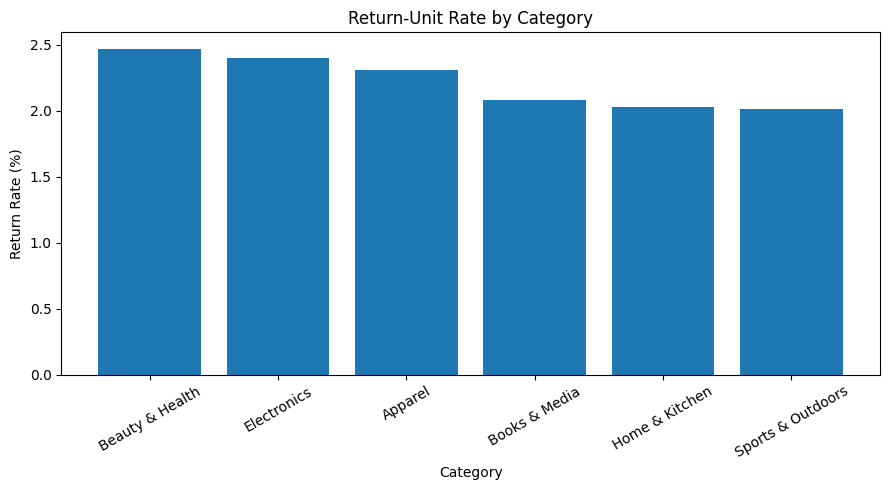

Interpretation: Beauty & Health has the highest unit return rate at 2.47%. Product quality, descriptions, packaging, and supplier performance should be reviewed.


In [ ]:
# BQ3 — Which categories have the highest return-unit rate?
return_by_category = order_items_clean.merge(
    products_clean[["product_id", "category"]], on="product_id", how="left"
).groupby("category").agg(
    total_units=("quantity", lambda s: np.abs(s).sum()),
    returned_units=("quantity", lambda s: np.abs(s[s < 0]).sum()),
).reset_index()
return_by_category["return_rate_percent"] = (
    100 * return_by_category["returned_units"] / return_by_category["total_units"]
)
return_by_category = return_by_category.sort_values("return_rate_percent", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(return_by_category["category"], return_by_category["return_rate_percent"])
plt.title("Return-Unit Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(CHART_DIR / "bq3_category_return_rate.png", dpi=160)
plt.show()

highest_return = return_by_category.iloc[0]
print(
    f"Interpretation: {highest_return['category']} has the highest unit return rate "
    f"at {highest_return['return_rate_percent']:.2f}%. Product quality, descriptions, "
    "packaging, and supplier performance should be reviewed."
)

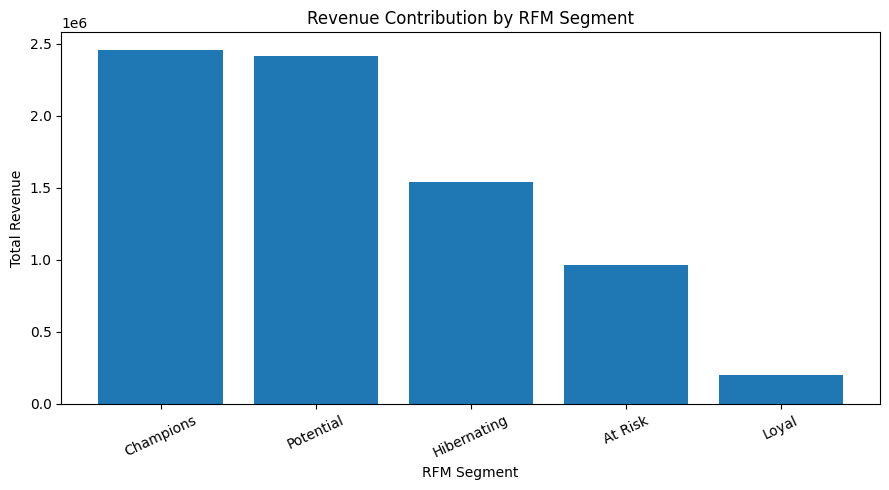

Interpretation: The Champions segment contributes the most revenue (2,455,158.51). Retention and personalized offers should prioritize this segment, while reactivation campaigns target At Risk customers.


In [ ]:
# BQ4 — Which RFM segments contribute the most revenue?
rfm_plot = rfm_summary.sort_values("total_revenue", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(rfm_plot["rfm_segment"], rfm_plot["total_revenue"])
plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(CHART_DIR / "bq4_rfm_segment_revenue.png", dpi=160)
plt.show()

top_segment = rfm_plot.iloc[0]
print(
    f"Interpretation: The {top_segment['rfm_segment']} segment contributes the most "
    f"revenue ({top_segment['total_revenue']:,.2f}). Retention and personalized offers "
    "should prioritize this segment, while reactivation campaigns target At Risk customers."
)

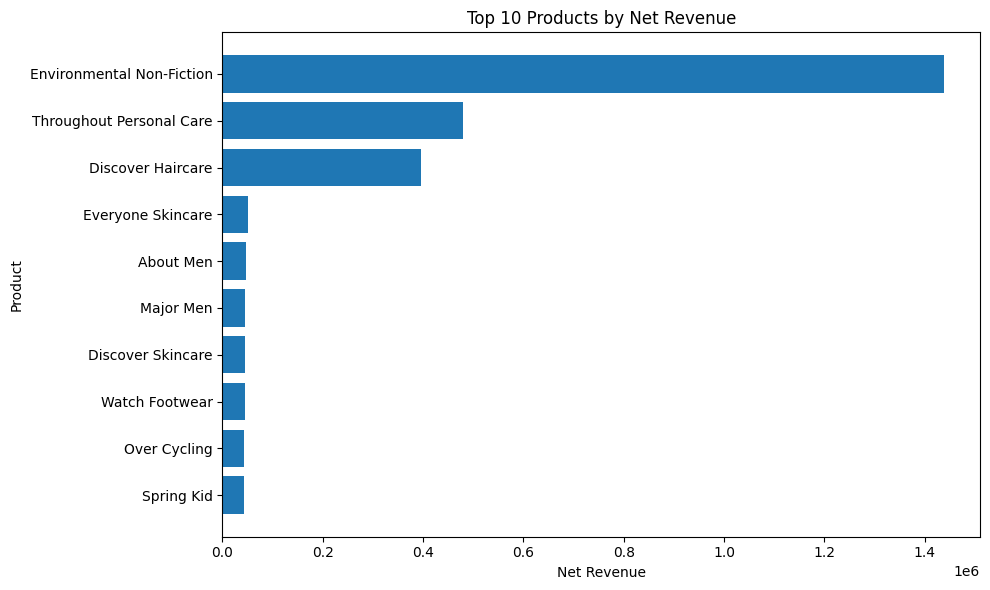

Interpretation: Environmental Non-Fiction is the strongest product by net revenue. Top products should receive priority in replenishment and recommendation placement.


In [ ]:
# BQ5 — Which products produce the most net revenue?
top_products = completed_transactions.groupby(["product_id", "name"], as_index=False)[
    "net_revenue"
].sum().sort_values("net_revenue", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_products["name"][::-1], top_products["net_revenue"][::-1])
plt.title("Top 10 Products by Net Revenue")
plt.xlabel("Net Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(CHART_DIR / "bq5_top_products.png", dpi=160)
plt.show()

print(
    f"Interpretation: {top_products.iloc[0]['name']} is the strongest product by net revenue. "
    "Top products should receive priority in replenishment and recommendation placement."
)

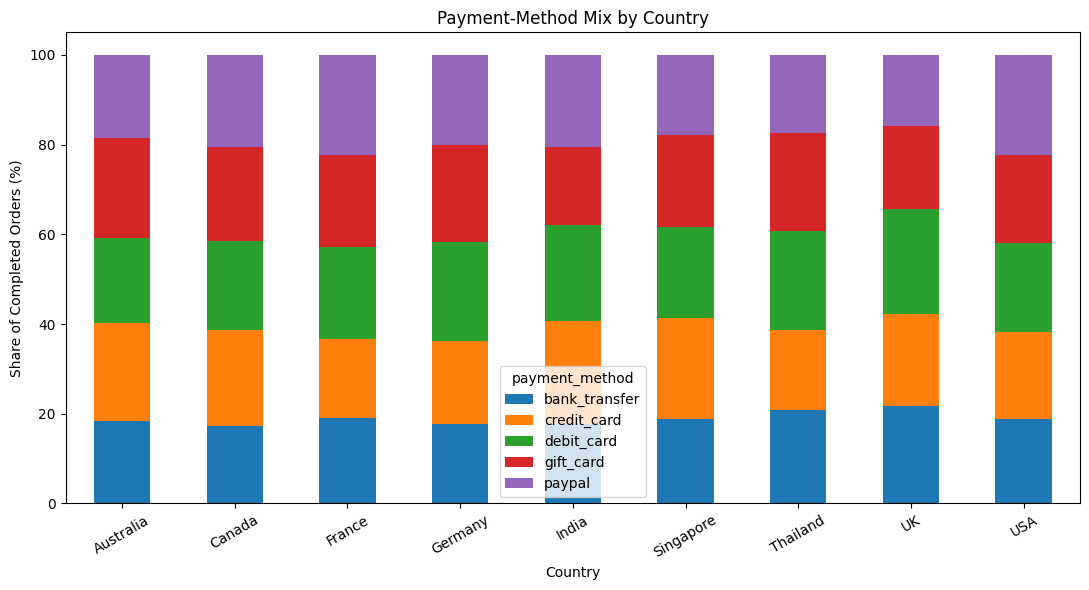

Interpretation: Payment preferences differ across countries. Checkout design and payment-provider partnerships should be localized to reduce payment friction.


In [ ]:
# BQ6 — How does payment-method usage vary by country?
payment_mix = query9_result.copy()
payment_pivot = payment_mix.pivot(
    index="country", columns="payment_method", values="payment_method_share_percent"
).fillna(0)

payment_pivot.plot(kind="bar", stacked=True, figsize=(11, 6))
plt.title("Payment-Method Mix by Country")
plt.xlabel("Country")
plt.ylabel("Share of Completed Orders (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(CHART_DIR / "bq6_payment_mix_country.png", dpi=160)
plt.show()

print(
    "Interpretation: Payment preferences differ across countries. Checkout design and "
    "payment-provider partnerships should be localized to reduce payment friction."
)

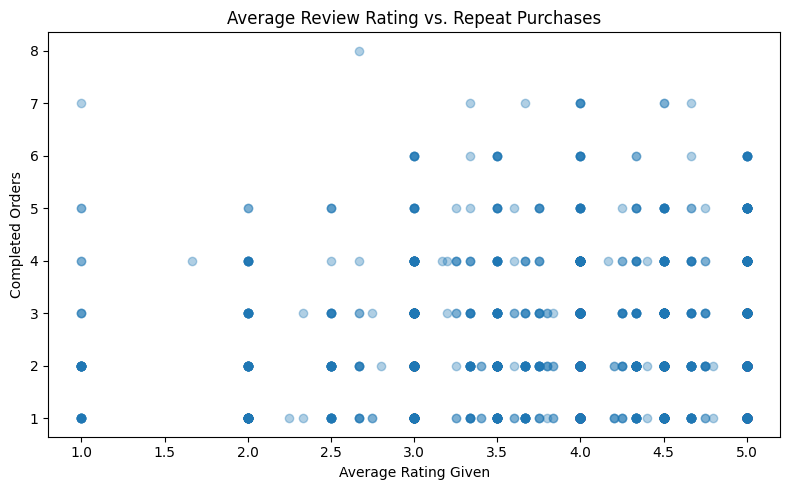

Interpretation: The Pearson correlation is 0.035. A value close to zero indicates that ratings alone are a weak predictor of repeat purchase; customer value and recency should also be considered.


In [ ]:
# BQ7 — Are better review ratings associated with repeat purchase?
valid_reviews = reviews_clean.dropna(subset=["rating"])
customer_ratings = valid_reviews.groupby("customer_id", as_index=False)["rating"].mean().rename(
    columns={"rating": "average_rating"}
)
repeat_orders = completed_orders_indexed.reset_index().groupby("customer_id", as_index=False)[
    "order_id"
].nunique().rename(columns={"order_id": "completed_orders"})
rating_repeat = customer_ratings.merge(repeat_orders, on="customer_id", how="inner")
correlation = rating_repeat["average_rating"].corr(rating_repeat["completed_orders"])

plt.figure(figsize=(8, 5))
plt.scatter(rating_repeat["average_rating"], rating_repeat["completed_orders"], alpha=0.35)
plt.title("Average Review Rating vs. Repeat Purchases")
plt.xlabel("Average Rating Given")
plt.ylabel("Completed Orders")
plt.tight_layout()
plt.savefig(CHART_DIR / "bq7_rating_repeat_purchase.png", dpi=160)
plt.show()

print(
    f"Interpretation: The Pearson correlation is {correlation:.3f}. "
    "A value close to zero indicates that ratings alone are a weak predictor of repeat purchase; "
    "customer value and recency should also be considered."
)

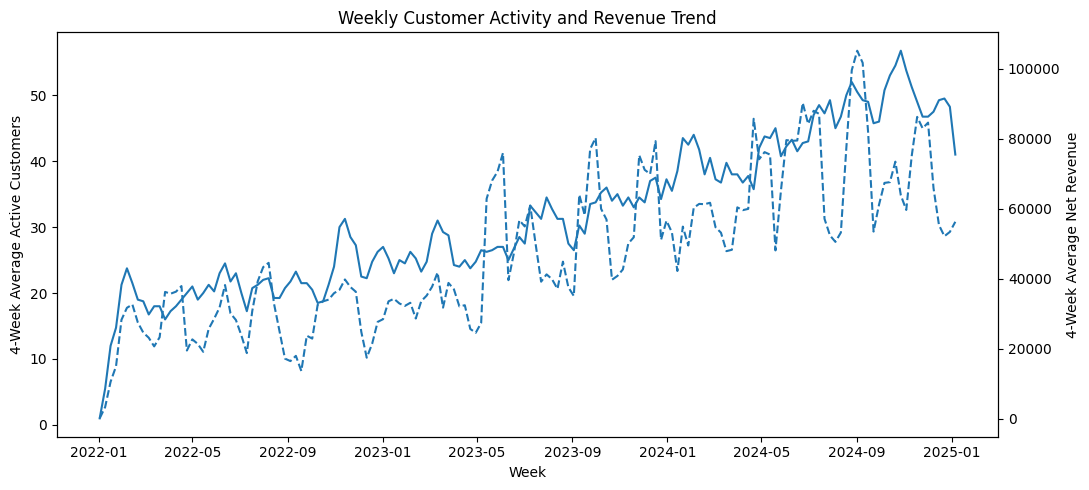

Interpretation: The moving averages show whether customer engagement and revenue are moving together. Divergence may signal changes in order value, product mix, discount intensity, or customer quality.


In [ ]:
# BQ8 — How are weekly active customers and revenue trending?
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(weekly_time_series.index, weekly_time_series["active_customers_4_week_ma"])
ax1.set_xlabel("Week")
ax1.set_ylabel("4-Week Average Active Customers")

ax2 = ax1.twinx()
ax2.plot(weekly_time_series.index, weekly_time_series["revenue_4_week_ma"], linestyle="--")
ax2.set_ylabel("4-Week Average Net Revenue")

plt.title("Weekly Customer Activity and Revenue Trend")
fig.tight_layout()
plt.savefig(CHART_DIR / "bq8_weekly_activity_revenue.png", dpi=160)
plt.show()

print(
    "Interpretation: The moving averages show whether customer engagement and revenue "
    "are moving together. Divergence may signal changes in order value, product mix, "
    "discount intensity, or customer quality."
)

In [ ]:
# Save Phase 4 insight tables and an overall requirement checklist.
business_tables = {
    "bq1_monthly_revenue.csv": monthly_revenue_insight,
    "bq2_category_performance.csv": category_performance,
    "bq3_return_rates.csv": return_by_category,
    "bq4_rfm_segment_revenue.csv": rfm_plot,
    "bq5_top_products.csv": top_products,
    "bq6_payment_mix.csv": payment_mix,
    "bq7_rating_repeat_purchase.csv": rating_repeat,
    "bq8_weekly_activity.csv": weekly_time_series.reset_index(),
}
for filename, frame in business_tables.items():
    frame.to_csv(TABLE_DIR / filename, index=False)

requirements_checklist = pd.DataFrame({
    "phase": [
        "Phase 1", "Phase 1", "Phase 2", "Phase 2", "Phase 2",
        "Phase 3", "Phase 3", "Phase 3", "Phase 3",
        "Phase 4", "Phase 4", "Phase 4"
    ],
    "requirement": [
        "10 SQL queries", "SQL results connected to pandas",
        "Missing values, duplicates, dates and outliers",
        "External-file integration and one-source SKU reporting",
        "Pivot table, time series and clean-data exports",
        "RFM segmentation with NumPy",
        "Cosine similarity with NumPy",
        "Regression using Normal Equation",
        "Monte Carlo simulation >= 5,000 trials",
        "8 business questions answered",
        "Charts generated",
        "Business interpretations written"
    ],
    "completed": [True] * 12
})
requirements_checklist.to_csv(TABLE_DIR / "phase1_to_phase4_requirements_checklist.csv", index=False)
requirements_checklist

,phase,requirement,completed
0,Phase 1,10 SQL queries,True
1,Phase 1,SQL results connected to pandas,True
2,Phase 2,"Missing values, duplicates, dates and outliers",True
3,Phase 2,External-file integration and one-source SKU r...,True
4,Phase 2,"Pivot table, time series and clean-data exports",True
5,Phase 3,RFM segmentation with NumPy,True
6,Phase 3,Cosine similarity with NumPy,True
7,Phase 3,Regression using Normal Equation,True
8,Phase 3,"Monte Carlo simulation >= 5,000 trials",True
9,Phase 4,8 business questions answered,True


## Final Conclusion

The notebook completes Phase 1 through Phase 4 using reproducible code and the supplied UrbanCart data. All query results, cleaned data, model outputs, business tables, and charts are exported into the project folders for submission and review.